### SENTINEL — Transfer Learning Lane Detection

**Notebook 04** — MobileNetV2 backbone (ImageNet pretrained) fine-tuned for multi-task
lane detection. Two-phase training: frozen backbone → partial unfreeze.

Consumes `processed/labels_{train,val,test}.json` and `processed/poly_norm_stats.npz`
from Notebooks 01 and 03.

**Architecture:**
```
MobileNetV2.features (pretrained, 1280 channels out)
  └─ AdaptiveAvgPool2d(1)      → 1280-d vector
  └─ FC(1280→256) → ReLU → Dropout(0.3)
       ├─ Head A: FC(256→1) + sigmoid   → has_lane
       └─ Head B: FC(256→6)             → [left_a,b,c | right_a,b,c] normalised
```

**Training:**
- Phase 1: freeze backbone features, train heads 10 epochs @ lr=1e-3
- Phase 2: unfreeze last 3 backbone layers, fine-tune 20 epochs @ lr=1e-4

---
## Cell 1 — Imports and config

In [1]:
import json
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# ── Constants (must match notebooks 01–03) ─────────────────────
IMG_W, IMG_H  = 320, 180
LOOKAHEAD_PX  = 45
SEED          = 42
PROCESSED_DIR = Path("processed")

# ── ImageNet normalisation (MobileNetV2 requirement) ──────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ── Training hyperparameters ───────────────────────────────────
BATCH_SIZE    = 32
LR_PHASE1     = 1e-3     # heads only
LR_PHASE2     = 1e-4     # fine-tune backbone
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
LAMBDA_POLY   = 1.0
WEIGHT_DECAY  = 1e-4

# ── Paths ──────────────────────────────────────────────────────
MODEL_PATH      = PROCESSED_DIR / "transfer_cnn.pth"
NORM_STATS_PATH = PROCESSED_DIR / "poly_norm_stats.npz"

# ── Device ─────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device:         {DEVICE}")
print(f"Resolution:     {IMG_W}x{IMG_H}")
print(f"Batch size:     {BATCH_SIZE}")
print(f"Phase 1:        {EPOCHS_PHASE1} epochs @ lr={LR_PHASE1}  (backbone frozen)")
print(f"Phase 2:        {EPOCHS_PHASE2} epochs @ lr={LR_PHASE2}  (unfreeze last 3 layers)")
print(f"Lambda poly:    {LAMBDA_POLY}  |  Weight decay: {WEIGHT_DECAY}")

Device:         cuda
Resolution:     320x180
Batch size:     32
Phase 1:        10 epochs @ lr=0.001  (backbone frozen)
Phase 2:        20 epochs @ lr=0.0001  (unfreeze last 3 layers)
Lambda poly:    1.0  |  Weight decay: 0.0001


---
## Cell 2 — Load labels and polynomial normalisation stats

Polynomial normalisation parameters (`POLY_MEAN`, `POLY_STD`) were computed on the
training set in Notebook 03 and saved to `processed/poly_norm_stats.npz`. We load
them here so that both models use identical normalisation — essential for a fair
comparison in the metrics table.

In [2]:
with open(PROCESSED_DIR / "labels_train.json", "r", encoding="utf-8") as f:
    train_labels = json.load(f)
with open(PROCESSED_DIR / "labels_val.json", "r", encoding="utf-8") as f:
    val_labels = json.load(f)
with open(PROCESSED_DIR / "labels_test.json", "r", encoding="utf-8") as f:
    test_labels = json.load(f)

# Load poly normalisation stats from notebook 03
stats = np.load(str(NORM_STATS_PATH))
POLY_MEAN = stats["mean"].astype(np.float32)
POLY_STD  = stats["std"].astype(np.float32)

print(f"Train: {len(train_labels)}  |  Val: {len(val_labels)}  |  Test: {len(test_labels)}")
print(f"\nPoly normalisation loaded from: {NORM_STATS_PATH}")
coeff_names = ["left_a", "left_b", "left_c", "right_a", "right_b", "right_c"]
print(f"  {'Coeff':<10}  {'Mean':>12}  {'Std':>12}")
for name, m, s in zip(coeff_names, POLY_MEAN, POLY_STD):
    print(f"  {name:<10}  {m:12.6f}  {s:12.6f}")

Train: 2538  |  Val: 543  |  Test: 545

Poly normalisation loaded from: processed/poly_norm_stats.npz
  Coeff               Mean           Std
  left_a         -0.000198      0.007395
  left_b         -1.155551      1.571537
  left_c        230.113647     84.208046
  right_a         0.000589      0.014500
  right_b         1.424764      2.770885
  right_c        75.286133    137.289307


---
## Cell 3 — LaneDataset with ImageNet normalisation

MobileNetV2 was pretrained on ImageNet with `mean=[0.485, 0.456, 0.406]` and
`std=[0.229, 0.224, 0.225]` (per-channel, RGB). Applying the same normalisation
keeps the pretrained feature distributions valid, which is critical for transfer
learning — using raw `[0,1]` pixel values would require the backbone to adapt
its feature statistics from scratch, negating the benefit of pretraining.

In [3]:
class LaneDatasetImageNet(Dataset):
    """Lane dataset with ImageNet-normalised input for MobileNetV2."""

    def __init__(self, labels, poly_mean, poly_std):
        self.labels    = labels
        self.poly_mean = poly_mean
        self.poly_std  = poly_std
        # Pre-convert constants to float32 for vectorised normalisation
        self._mean = IMAGENET_MEAN.reshape(1, 1, 3)
        self._std  = IMAGENET_STD.reshape(1, 1, 3)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl = self.labels[idx]

        img = cv2.imread(lbl["image"])
        if img is None:
            img = np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = (img - self._mean) / self._std          # ImageNet normalise
        img_t = torch.from_numpy(img.transpose(2, 0, 1))  # CHW

        has_lane_t = torch.tensor([1.0 if lbl["has_lane"] else 0.0])

        if lbl["has_lane"]:
            raw = np.array(lbl["left_poly"] + lbl["right_poly"], dtype=np.float32)
            poly_t = torch.from_numpy((raw - self.poly_mean) / self.poly_std)
        else:
            poly_t = torch.zeros(6, dtype=torch.float32)

        return img_t, has_lane_t, poly_t


train_ds = LaneDatasetImageNet(train_labels, POLY_MEAN, POLY_STD)
val_ds   = LaneDatasetImageNet(val_labels,   POLY_MEAN, POLY_STD)
test_ds  = LaneDatasetImageNet(test_labels,  POLY_MEAN, POLY_STD)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

imgs, cls_t, poly_t = next(iter(train_loader))
print(f"\nBatch shapes — img: {tuple(imgs.shape)}, cls: {tuple(cls_t.shape)}, poly: {tuple(poly_t.shape)}")

Train batches: 80
Val batches:   17
Test batches:  18

Batch shapes — img: (32, 3, 180, 320), cls: (32, 1), poly: (32, 6)


---
## Cell 4 — SentinelTransferCNN architecture

MobileNetV2's `features` block is a Sequential of 19 InvertedResidual/ConvBNReLU
modules (indices 0–18). With input `3×180×320` the spatial output is approximately
`1280×6×10` before the global pool, yielding a 1280-d feature vector.

| Stage | Output shape | Notes |
|---|---|---|
| Input | 3×180×320 | ImageNet-normalised |
| MobileNetV2.features | 1280×6×10 | Pretrained backbone |
| AdaptiveAvgPool2d(1) | 1280×1×1 | Global average |
| FC(1280→256) + ReLU + Drop(0.3) | 256 | Custom neck |
| Head A: FC(256→1) + sigmoid | scalar | has_lane |
| Head B: FC(256→6) | 6 floats | normalised poly coeffs |

In [4]:
class SentinelTransferCNN(nn.Module):
    """MobileNetV2-based multi-task model for lane polynomial regression."""

    def __init__(self):
        super().__init__()
        backbone     = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features           # 1280 output channels
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.neck     = nn.Sequential(
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
        )
        self.head_cls  = nn.Linear(256, 1)
        self.head_poly = nn.Linear(256, 6)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.neck(x)
        return torch.sigmoid(self.head_cls(x)), self.head_poly(x)


model = SentinelTransferCNN().to(DEVICE)

n_backbone = sum(p.numel() for p in model.features.parameters())
n_head     = sum(p.numel() for p in list(model.neck.parameters()) +
                             list(model.head_cls.parameters()) +
                             list(model.head_poly.parameters()))
print(f"SentinelTransferCNN")
print(f"  Backbone params:  {n_backbone:,}")
print(f"  Neck+head params: {n_head:,}")
print(f"  Total params:     {n_backbone + n_head:,}")

with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_H, IMG_W, device=DEVICE)
    cls_out, poly_out = model(dummy)
print(f"\nOutput shapes — cls: {tuple(cls_out.shape)}, poly: {tuple(poly_out.shape)}")

SentinelTransferCNN
  Backbone params:  2,223,872
  Neck+head params: 329,735
  Total params:     2,553,607

Output shapes — cls: (2, 1), poly: (2, 6)


---
## Cell 5 — Loss function and epoch runner

Same multi-task loss as Notebook 03:
`L = BCE(has_lane) + λ * MSE(polynomials)` with λ=1.0.
Polynomial MSE is computed only on `has_lane=True` samples.

In [5]:
def multitask_loss(pred_cls, pred_poly, true_cls, true_poly):
    """Returns (total_loss, bce_scalar, mse_scalar)."""
    bce = F.binary_cross_entropy(pred_cls, true_cls)
    lane_mask = true_cls.squeeze(1).bool()
    if lane_mask.sum() > 0:
        mse = F.mse_loss(pred_poly[lane_mask], true_poly[lane_mask])
    else:
        mse = torch.tensor(0.0, device=pred_cls.device)
    total = bce + LAMBDA_POLY * mse
    return total, bce.item(), mse.item()


def run_epoch(loader, model, optimizer=None):
    """One training or validation pass. Returns (avg_total, avg_bce, avg_mse)."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_sum = bce_sum = mse_sum = 0.0
    n_batches = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, cls_t, poly_t in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            cls_t  = cls_t.to(DEVICE, non_blocking=True)
            poly_t = poly_t.to(DEVICE, non_blocking=True)

            pred_cls, pred_poly = model(imgs)
            loss, bce_v, mse_v  = multitask_loss(pred_cls, pred_poly, cls_t, poly_t)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_sum += loss.item()
            bce_sum   += bce_v
            mse_sum   += mse_v
            n_batches += 1

    n = max(n_batches, 1)
    return total_sum / n, bce_sum / n, mse_sum / n


print("Loss function and epoch runner defined.")

Loss function and epoch runner defined.


---
## Cell 6 — Phase 1: frozen backbone (10 epochs)

All backbone feature parameters are frozen. Only the neck and task heads are
trained. This lets the randomly-initialised heads converge to a reasonable
solution before the pretrained backbone weights are disturbed.

In [6]:
# ── Freeze backbone ───────────────────────────────────────────
for param in model.features.parameters():
    param.requires_grad = False

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1: backbone frozen  |  trainable params: {n_trainable:,}")

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
)

history_p1 = {"train_loss": [], "val_loss": [],
               "train_mse":  [], "val_mse":  []}

best_val_loss = float("inf")
best_epoch_p1 = 0

print(f"\n{'Epoch':>6}  {'Train':>9}  {'Val':>9}  {'MSE_v':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, _, tr_mse = run_epoch(train_loader, model, optimizer_p1)
    vl_loss, _, vl_mse = run_epoch(val_loader,   model)

    history_p1["train_loss"].append(tr_loss)
    history_p1["val_loss"].append(vl_loss)
    history_p1["train_mse"].append(tr_mse)
    history_p1["val_mse"].append(vl_mse)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_epoch_p1 = epoch
        torch.save(model.state_dict(), str(MODEL_PATH))
        tag = " ◀ best"
    else:
        tag = ""

    print(f"{epoch:6d}  {tr_loss:9.4f}  {vl_loss:9.4f}  {vl_mse:8.4f}{tag}")

print(f"\nPhase 1 complete. Best epoch {best_epoch_p1}, val_loss={best_val_loss:.4f}")

Phase 1: backbone frozen  |  trainable params: 329,735

 Epoch      Train        Val     MSE_v
----------------------------------------
     1     1.0766     0.5917    0.5870 ◀ best
     2     0.9839     0.5782    0.5759 ◀ best
     3     0.9537     0.6411    0.6403
     4     0.9504     0.5772    0.5767 ◀ best
     5     0.9203     0.5600    0.5596 ◀ best
     6     0.9120     0.5598    0.5588 ◀ best
     7     0.8841     0.5504    0.5501 ◀ best
     8     0.8737     0.5544    0.5540
     9     0.8626     0.5518    0.5516
    10     0.8837     0.5515    0.5514

Phase 1 complete. Best epoch 7, val_loss=0.5504


---
## Cell 7 — Phase 2: unfreeze last 3 backbone layers (20 epochs)

Load the best Phase 1 checkpoint, then unfreeze `features[16]`, `features[17]`,
and `features[18]` (the final three MobileNetV2 modules). These are the layers most
likely to encode high-level visual features that benefit from domain adaptation to
road scenes. Earlier layers (edges, textures) are left frozen.

LR is reduced 10× to `1e-4` to prevent catastrophic forgetting.

In [7]:
# Load best Phase 1 weights
model.load_state_dict(torch.load(str(MODEL_PATH), map_location=DEVICE))

# ── Unfreeze last 3 backbone layers ───────────────────────────
for layer_idx in [-3, -2, -1]:   # features[16], features[17], features[18]
    for param in model.features[layer_idx].parameters():
        param.requires_grad = True

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2: last 3 layers unfrozen  |  trainable params: {n_trainable:,}")

optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2, weight_decay=WEIGHT_DECAY
)
scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="min", factor=0.5, patience=5, min_lr=1e-6
)

history_p2 = {"train_loss": [], "val_loss": [],
               "train_mse":  [], "val_mse":  []}

patience_counter = 0
PATIENCE_P2      = 10
best_epoch_p2    = 0

print(f"\n{'Epoch':>6}  {'Train':>9}  {'Val':>9}  {'MSE_v':>8}  {'LR':>9}")
print("-" * 52)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, _, tr_mse = run_epoch(train_loader, model, optimizer_p2)
    vl_loss, _, vl_mse = run_epoch(val_loader,   model)

    history_p2["train_loss"].append(tr_loss)
    history_p2["val_loss"].append(vl_loss)
    history_p2["train_mse"].append(tr_mse)
    history_p2["val_mse"].append(vl_mse)

    scheduler_p2.step(vl_loss)
    current_lr = optimizer_p2.param_groups[0]["lr"]

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_epoch_p2 = epoch
        patience_counter = 0
        torch.save(model.state_dict(), str(MODEL_PATH))
        tag = " ◀ best"
    else:
        patience_counter += 1
        tag = ""

    print(f"{epoch:6d}  {tr_loss:9.4f}  {vl_loss:9.4f}  {vl_mse:8.4f}  {current_lr:9.2e}{tag}")

    if patience_counter >= PATIENCE_P2:
        print(f"\nEarly stop at epoch {epoch}")
        break

print(f"\nPhase 2 complete. Best epoch {best_epoch_p2} (Phase 2), val_loss={best_val_loss:.4f}")
print(f"Model saved to: {MODEL_PATH}")

Phase 2: last 3 layers unfrozen  |  trainable params: 1,535,815

 Epoch      Train        Val     MSE_v         LR
----------------------------------------------------
     1     0.8567     0.5094    0.5091   1.00e-04 ◀ best
     2     0.7815     0.4896    0.4894   1.00e-04 ◀ best
     3     0.6506     0.4734    0.4731   1.00e-04 ◀ best
     4     0.7231     0.4947    0.4945   1.00e-04
     5     0.4998     0.5296    0.5294   1.00e-04
     6     0.4593     0.4945    0.4944   1.00e-04
     7     0.4264     0.5287    0.5285   1.00e-04
     8     0.3728     0.5013    0.5011   1.00e-04
     9     0.3530     0.5652    0.5651   5.00e-05
    10     0.3095     0.5090    0.5088   5.00e-05
    11     0.2790     0.5454    0.5453   5.00e-05
    12     0.2861     0.5295    0.5294   5.00e-05
    13     0.2494     0.5324    0.5322   5.00e-05

Early stop at epoch 13

Phase 2 complete. Best epoch 3 (Phase 2), val_loss=0.4734
Model saved to: processed/transfer_cnn.pth


---
## Cell 8 — Loss curves (Phase 1 + Phase 2)

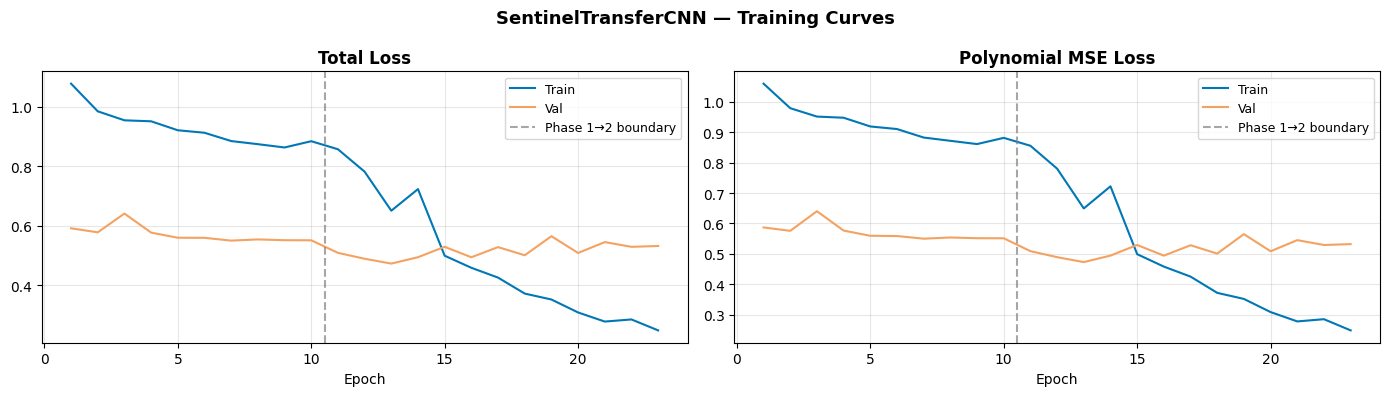

Saved: processed/transfer_loss_curves.png

Final train loss: 0.2494
Final val loss:   0.5324
Val − Train gap:   0.2830  (overfitting)


In [8]:
# Combine Phase 1 and Phase 2 histories for plotting
combined_train = history_p1["train_loss"] + history_p2["train_loss"]
combined_val   = history_p1["val_loss"]   + history_p2["val_loss"]
combined_train_mse = history_p1["train_mse"] + history_p2["train_mse"]
combined_val_mse   = history_p1["val_mse"]   + history_p2["val_mse"]

n_p1 = len(history_p1["train_loss"])
epochs_all = list(range(1, len(combined_train) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("SentinelTransferCNN — Training Curves", fontsize=13, fontweight="bold")

for ax, (tr, vl, title) in zip(axes, [
    (combined_train,     combined_val,     "Total Loss"),
    (combined_train_mse, combined_val_mse, "Polynomial MSE Loss"),
]):
    ax.plot(epochs_all, tr, label="Train", color="#0077B6", linewidth=1.5)
    ax.plot(epochs_all, vl, label="Val",   color="#F4A261", linewidth=1.5)
    ax.axvline(n_p1 + 0.5, color="gray", linestyle="--", alpha=0.7,
               label="Phase 1→2 boundary")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
curves_path = PROCESSED_DIR / "transfer_loss_curves.png"
plt.savefig(str(curves_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

gap = combined_val[-1] - combined_train[-1]
print(f"\nFinal train loss: {combined_train[-1]:.4f}")
print(f"Final val loss:   {combined_val[-1]:.4f}")
print(f"Val − Train gap:   {gap:.4f}  ({'overfitting' if gap > 0.05 else 'acceptable'})")

---
## Cell 9 — Test set evaluation

Same metrics as Notebook 03 for direct comparison:
- `has_lane` accuracy (threshold 0.5)
- Polynomial RMSE (pixel error at 30 y-values in the ROI)
- Steering error MAE at the lookahead row
- **Inference time** — mean ms per image (on GPU if available)

Results saved to `processed/metrics_transfer.json`.

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(str(MODEL_PATH), map_location=DEVICE))
model.eval()

all_pred_cls  = []
all_pred_poly = []
all_true_cls  = []
all_true_poly_norm = []

with torch.no_grad():
    for imgs, cls_t, poly_t in tqdm(test_loader, desc="Evaluating test set"):
        imgs = imgs.to(DEVICE)
        pred_cls_b, pred_poly_norm_b = model(imgs)

        mn = torch.from_numpy(POLY_MEAN).to(DEVICE)
        st = torch.from_numpy(POLY_STD).to(DEVICE)
        pred_poly_raw_b = pred_poly_norm_b * st + mn

        all_pred_cls.extend(pred_cls_b.cpu().squeeze(1).tolist())
        all_pred_poly.extend(pred_poly_raw_b.cpu().tolist())
        all_true_cls.extend(cls_t.squeeze(1).tolist())
        all_true_poly_norm.extend(poly_t.tolist())

true_poly_raw = np.array(all_true_poly_norm, dtype=np.float32) * POLY_STD + POLY_MEAN

# ── Classification accuracy ───────────────────────────────────
pred_cls_bin = [1 if p >= 0.5 else 0 for p in all_pred_cls]
true_cls_bin = [int(round(v)) for v in all_true_cls]
accuracy = sum(p == t for p, t in zip(pred_cls_bin, true_cls_bin)) / len(true_cls_bin)

# ── Polynomial RMSE and Steering MAE ─────────────────────────
roi_y_start = int(IMG_H * 0.40)
ys_eval     = np.linspace(roi_y_start, IMG_H - 1, 30)
y_la        = float(IMG_H - LOOKAHEAD_PX)

poly_rmses = []
steer_maes = []

for p_poly, t_poly, has_l in zip(all_pred_poly, true_poly_raw, all_true_cls):
    if has_l < 0.5:
        continue
    p_left  = p_poly[:3];  p_right = p_poly[3:]
    t_left  = t_poly[:3];  t_right = t_poly[3:]
    sq_errs = (
        [(np.polyval(p_left,  y) - np.polyval(t_left,  y)) ** 2 for y in ys_eval] +
        [(np.polyval(p_right, y) - np.polyval(t_right, y)) ** 2 for y in ys_eval]
    )
    poly_rmses.append(np.sqrt(np.mean(sq_errs)))

    pred_mid = (np.polyval(p_left, y_la) + np.polyval(p_right, y_la)) / 2.0
    true_mid = (np.polyval(t_left, y_la) + np.polyval(t_right, y_la)) / 2.0
    steer_maes.append(abs(pred_mid - true_mid))

poly_rmses = np.array(poly_rmses)
steer_maes = np.array(steer_maes)

# ── Inference time benchmark (single image, 100 runs) ────────
model.eval()
sample_img = test_ds[0][0].unsqueeze(0).to(DEVICE)
# Warm-up
with torch.no_grad():
    for _ in range(10):
        _ = model(sample_img)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(100):
        _ = model(sample_img)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
t1 = time.perf_counter()
inference_ms = (t1 - t0) / 100 * 1000

# ── Print results ─────────────────────────────────────────────
print(f"{'='*58}")
print(f"  TRANSFER CNN (MobileNetV2) — TEST SET RESULTS")
print(f"{'='*58}")
print(f"  {'Metric':<36s}  {'Value':>12s}")
print(f"  {'-'*50}")
print(f"  {'has_lane accuracy':<36s}  {accuracy:>12.4f}")
print(f"  {'Poly RMSE mean (px)':<36s}  {poly_rmses.mean():>12.2f}")
print(f"  {'Poly RMSE median (px)':<36s}  {np.median(poly_rmses):>12.2f}")
print(f"  {'Poly RMSE std (px)':<36s}  {poly_rmses.std():>12.2f}")
print(f"  {'Steering MAE mean (px)':<36s}  {steer_maes.mean():>12.2f}")
print(f"  {'Steering MAE median (px)':<36s}  {np.median(steer_maes):>12.2f}")
print(f"  {'Inference time (ms/img)':<36s}  {inference_ms:>12.2f}")
print(f"  {'-'*50}")
print(f"  Evaluated on {len(poly_rmses)} samples (has_lane=True)")

# Save for comparison table
metrics = {
    "model":               "transfer_mobilenetv2",
    "accuracy":            float(accuracy),
    "poly_rmse_mean":      float(poly_rmses.mean()),
    "poly_rmse_median":    float(np.median(poly_rmses)),
    "poly_rmse_std":       float(poly_rmses.std()),
    "steering_mae_mean":   float(steer_maes.mean()),
    "steering_mae_median": float(np.median(steer_maes)),
    "inference_ms":        float(inference_ms),
    "best_val_loss":       float(best_val_loss),
}
with open(str(PROCESSED_DIR / "metrics_transfer.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)
print(f"\nMetrics saved to: {PROCESSED_DIR / 'metrics_transfer.json'}")

Evaluating test set: 100%|██████████| 18/18 [00:03<00:00,  5.63it/s]


  TRANSFER CNN (MobileNetV2) — TEST SET RESULTS
  Metric                                       Value
  --------------------------------------------------
  has_lane accuracy                           1.0000
  Poly RMSE mean (px)                          56.78
  Poly RMSE median (px)                        26.61
  Poly RMSE std (px)                           62.56
  Steering MAE mean (px)                       44.58
  Steering MAE median (px)                     15.49
  Inference time (ms/img)                       5.87
  --------------------------------------------------
  Evaluated on 545 samples (has_lane=True)

Metrics saved to: processed/metrics_transfer.json


---
## Cell 10 — Test predictions visualisation

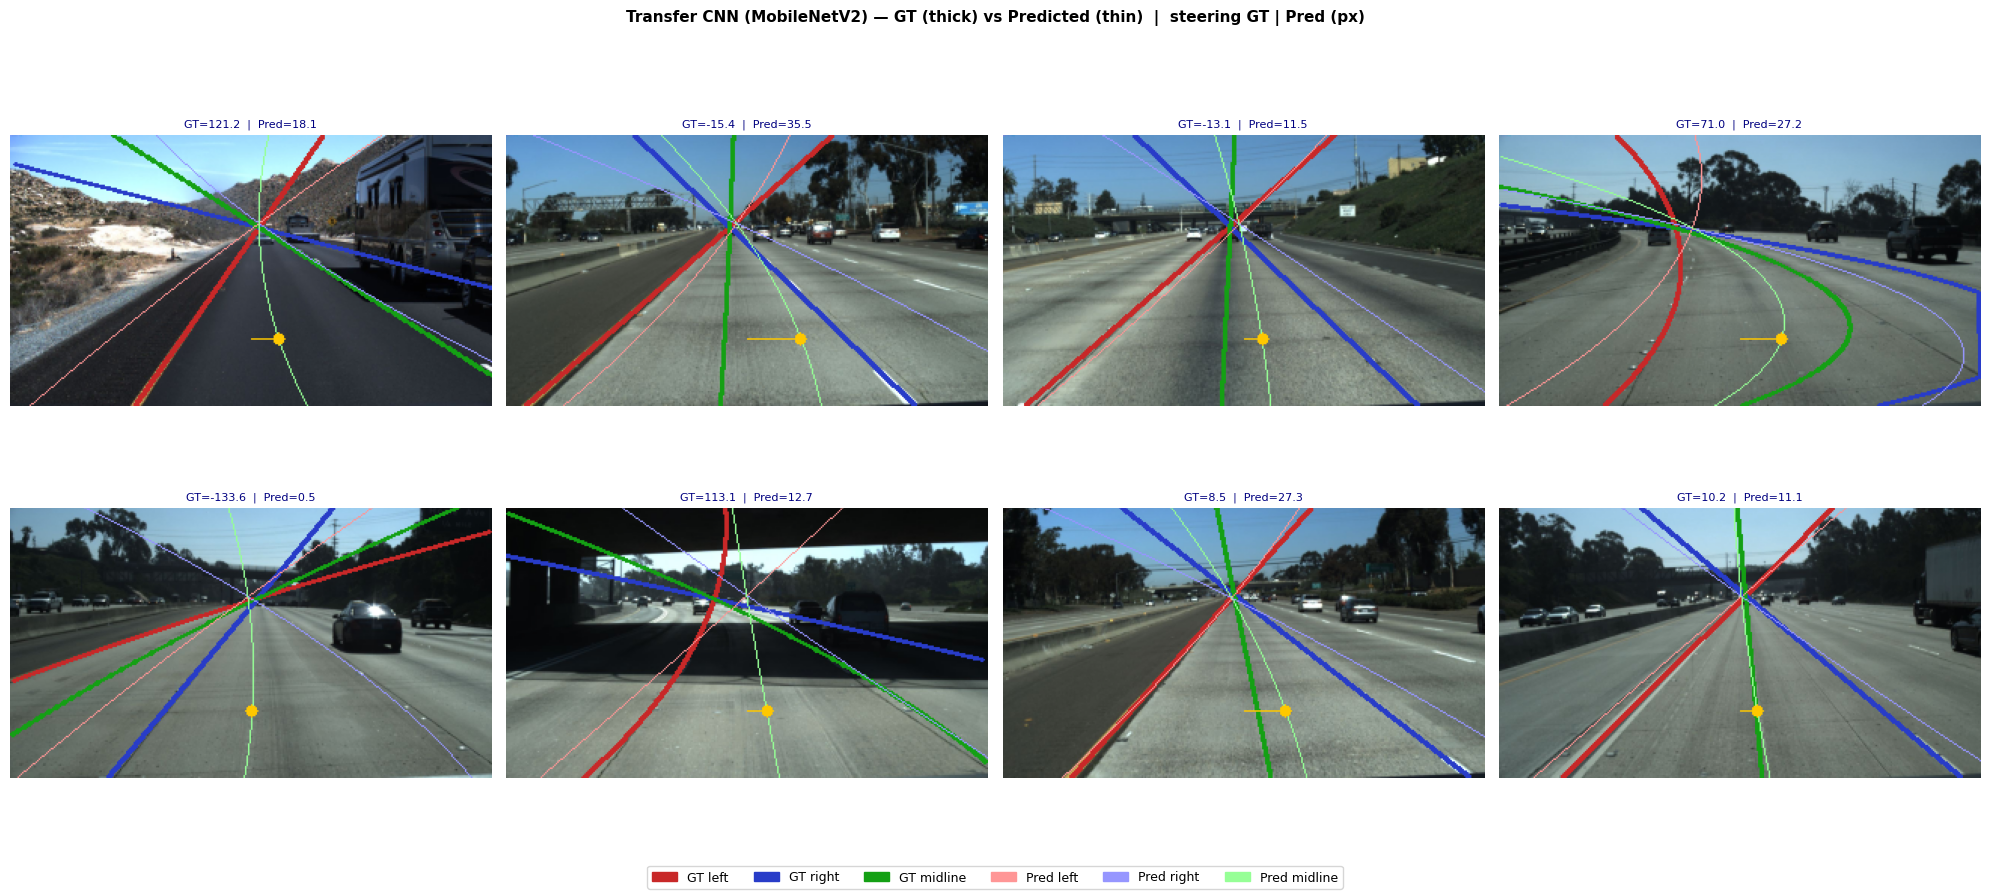

Saved: processed/transfer_test_predictions.png


In [10]:
def draw_poly_line(overlay, coeffs, color, thickness=2):
    pts = []
    for y in range(IMG_H):
        x = int(round(np.polyval(coeffs, y)))
        if 0 <= x < IMG_W:
            pts.append((x, y))
    for j in range(len(pts) - 1):
        cv2.line(overlay, pts[j], pts[j + 1], color, thickness)


rng = random.Random(SEED + 4)
vis_indices = rng.sample(range(len(test_labels)), min(8, len(test_labels)))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(
    "Transfer CNN (MobileNetV2) — GT (thick) vs Predicted (thin)  |  steering GT | Pred (px)",
    fontsize=11, fontweight="bold"
)

for ax, idx in zip(axes.flat, vis_indices):
    lbl = test_labels[idx]
    img = cv2.imread(lbl["image"])
    if img is None:
        ax.axis("off")
        continue

    overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    p_poly  = all_pred_poly[idx]
    p_left  = p_poly[:3];  p_right = p_poly[3:]
    p_mid   = [(l + r) / 2 for l, r in zip(p_left, p_right)]

    if lbl["has_lane"]:
        draw_poly_line(overlay, lbl["left_poly"],  (200,  40,  40), 2)
        draw_poly_line(overlay, lbl["right_poly"], ( 40,  60, 200), 2)
        draw_poly_line(overlay, lbl["mid_poly"],   ( 20, 160,  20), 2)

    draw_poly_line(overlay, p_left,  (255, 150, 150), 1)
    draw_poly_line(overlay, p_right, (150, 150, 255), 1)
    draw_poly_line(overlay, p_mid,   (150, 255, 150), 1)

    y_la_int = IMG_H - LOOKAHEAD_PX
    x_pred_mid = int(round((np.polyval(p_left, y_la_int) + np.polyval(p_right, y_la_int)) / 2))
    cv2.circle(overlay, (x_pred_mid, y_la_int), 4, (255, 200, 0), -1)
    cv2.line(overlay, (IMG_W // 2, y_la_int), (x_pred_mid, y_la_int), (255, 200, 0), 1)

    pred_steer = (np.polyval(p_left, y_la_int) + np.polyval(p_right, y_la_int)) / 2 - IMG_W / 2
    gt_steer   = lbl["steering_error"] if lbl["has_lane"] else 0.0

    ax.imshow(overlay)
    ax.set_title(f"GT={gt_steer:.1f}  |  Pred={pred_steer:.1f}", fontsize=8, color="navy")
    ax.axis("off")

patches = [
    mpatches.Patch(color=(200/255, 40/255,  40/255),  label="GT left"),
    mpatches.Patch(color=(40/255,  60/255,  200/255), label="GT right"),
    mpatches.Patch(color=(20/255,  160/255, 20/255),  label="GT midline"),
    mpatches.Patch(color=(255/255, 150/255, 150/255), label="Pred left"),
    mpatches.Patch(color=(150/255, 150/255, 255/255), label="Pred right"),
    mpatches.Patch(color=(150/255, 255/255, 150/255), label="Pred midline"),
]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=9)
plt.tight_layout()
vis_path = PROCESSED_DIR / "transfer_test_predictions.png"
plt.savefig(str(vis_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {vis_path}")

---
## Cell 11 — Model comparison table

Final comparison across all three approaches for the CIE-552 deliverable.


  MODEL COMPARISON — CIE-552 SENTINEL Lane Detection
  Metric                            Classical     Custom CNN       Transfer
  ----------------------------------------------------------------------
  has_lane Accuracy                    0.7945         1.0000         1.0000
  Poly RMSE mean (px)                   75.62          61.22          56.78
  Poly RMSE median (px)                     —          32.40          26.61
  Steering MAE mean (px)                40.81          45.15          44.58
  Steering MAE median (px)                  —          17.11          15.49
  Inference time (ms/img)           N/A (CPU)              —           5.87
  Detection Rate                        21.5%         100.0%         100.0%
  Notes:
  * Classical accuracy = HOG+SVM predicting pipeline detection success
  * Classical RMSE/MAE measured only on 21.5% detected subset
  * CNN models evaluated on full test set (545 samples)
  * Inference time measured on cuda (100 single-image forward passe

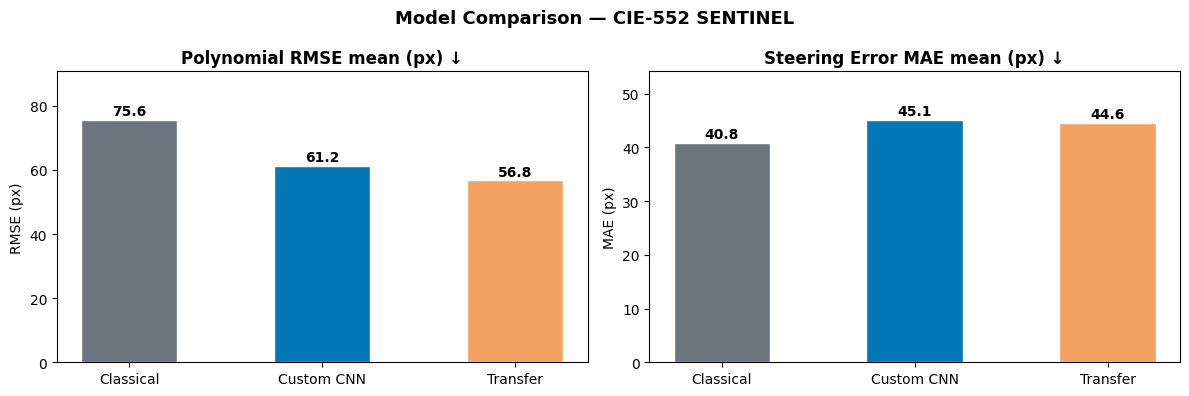


Saved: processed/model_comparison_chart.png

Notebook 04 complete. Next: 05_experiments.ipynb


In [11]:
# Load custom CNN metrics from notebook 03
with open(str(PROCESSED_DIR / "metrics_custom_cnn.json"), "r", encoding="utf-8") as f:
    cnn_m = json.load(f)

# Classical pipeline metrics (from notebook 02 outputs)
classical_m = {
    "model":             "classical_hog_svm",
    "accuracy":          0.7945,   # HOG+SVM accuracy (predicting pipeline success)
    "poly_rmse_mean":    75.62,    # on the 21.5% detected subset
    "steering_mae_mean": 40.81,
    "detection_rate":    0.215,    # 117/545
    "inference_ms":      None,     # CPU-bound, not benchmarked here
}

# Transfer CNN metrics (just computed)
with open(str(PROCESSED_DIR / "metrics_transfer.json"), "r", encoding="utf-8") as f:
    tr_m = json.load(f)

# ── Comparison table (printed) ────────────────────────────────
print(f"\n{'='*75}")
print(f"  MODEL COMPARISON — CIE-552 SENTINEL Lane Detection")
print(f"{'='*75}")
header = f"  {'Metric':<28} {'Classical':>14} {'Custom CNN':>14} {'Transfer':>14}"
print(header)
print(f"  {'-'*70}")

rows = [
    ("has_lane Accuracy",
     f"{classical_m['accuracy']:.4f}",
     f"{cnn_m['accuracy']:.4f}",
     f"{tr_m['accuracy']:.4f}"),
    ("Poly RMSE mean (px)",
     f"{classical_m['poly_rmse_mean']:.2f}",
     f"{cnn_m['poly_rmse_mean']:.2f}",
     f"{tr_m['poly_rmse_mean']:.2f}"),
    ("Poly RMSE median (px)",
     "—",
     f"{cnn_m['poly_rmse_median']:.2f}",
     f"{tr_m['poly_rmse_median']:.2f}"),
    ("Steering MAE mean (px)",
     f"{classical_m['steering_mae_mean']:.2f}",
     f"{cnn_m['steering_mae_mean']:.2f}",
     f"{tr_m['steering_mae_mean']:.2f}"),
    ("Steering MAE median (px)",
     "—",
     f"{cnn_m['steering_mae_median']:.2f}",
     f"{tr_m['steering_mae_median']:.2f}"),
    ("Inference time (ms/img)",
     "N/A (CPU)",
     "—",
     f"{tr_m['inference_ms']:.2f}"),
    ("Detection Rate",
     f"{classical_m['detection_rate']*100:.1f}%",
     "100.0%",
     "100.0%"),
]

for label, cl_val, cnn_val, tr_val in rows:
    print(f"  {label:<28} {cl_val:>14} {cnn_val:>14} {tr_val:>14}")

print(f"  {'='*70}")
print(f"  Notes:")
print(f"  * Classical accuracy = HOG+SVM predicting pipeline detection success")
print(f"  * Classical RMSE/MAE measured only on 21.5% detected subset")
print(f"  * CNN models evaluated on full test set (545 samples)")
print(f"  * Inference time measured on {DEVICE} (100 single-image forward passes)")

# ── Visual bar chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Comparison — CIE-552 SENTINEL", fontsize=13, fontweight="bold")

models = ["Classical", "Custom CNN", "Transfer"]
colors = ["#6C757D", "#0077B6", "#F4A261"]

# Poly RMSE
rmse_vals = [classical_m["poly_rmse_mean"], cnn_m["poly_rmse_mean"], tr_m["poly_rmse_mean"]]
bars = axes[0].bar(models, rmse_vals, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Polynomial RMSE mean (px) ↓", fontweight="bold")
axes[0].set_ylabel("RMSE (px)")
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, max(rmse_vals) * 1.2)

# Steering MAE
mae_vals = [classical_m["steering_mae_mean"], cnn_m["steering_mae_mean"], tr_m["steering_mae_mean"]]
bars = axes[1].bar(models, mae_vals, color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Steering Error MAE mean (px) ↓", fontweight="bold")
axes[1].set_ylabel("MAE (px)")
for bar, val in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(mae_vals) * 1.2)

plt.tight_layout()
chart_path = PROCESSED_DIR / "model_comparison_chart.png"
plt.savefig(str(chart_path), dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved: {chart_path}")
print("\nNotebook 04 complete. Next: 05_experiments.ipynb")